# Distributed ML with Ray — the hands-on half

The practical companion to **`ray_slides.html`**. Everything here runs on the cores you already
have; nothing needs a cluster. The point is that the *code* does not change when a cluster does
appear.

| Part | Deck slides | What you do |
|---|---|---|
| 0 · Setup | 12–13 | install, start a local Ray, see your resources |
| 1 · Tasks | 14–17 | `@ray.remote`, and a **measured** speedup across your cores |
| 2 · The object store | 9 | why `ray.put` matters, measured on a big array |
| 3 · Actors | 18 | state that lives beside the work |
| 4 · Ray Train | 20–23 | data-parallel PyTorch, same script for 1 or 100 workers |
| 5 · Advanced | 24–27 | `ray.wait`, resources, failures, when not to use Ray |

Everything runs in a throwaway `ray_demo/` folder; the last cell shuts Ray down.

<!-- ar -->
<div dir="rtl" lang="ar">

**التعلم الآلي الموزّع باستخدام Ray: الجزء العملي**

هذا الدفتر هو الجانب العملي لعرض `ray_slides.html`. كل ما هنا يعمل على أنوية جهازك الحالية، ولا يحتاج عنقوداً. الفكرة أن *الكود* لا يتغيّر عندما يتوفر عنقود لاحقاً.

| الجزء | شرائح العرض | ماذا تفعل |
|---|---|---|
| ٠ · الإعداد | 12–13 | التثبيت، وتشغيل Ray محلياً، ورؤية موارد جهازك |
| ١ · المهام | 14–17 | `@ray.remote`، وتسريع **مقاس** على أنويتك |
| ٢ · مخزن الكائنات | 9 | لماذا يهم `ray.put`، مقاساً على مصفوفة كبيرة |
| ٣ · الكائنات الفاعلة | 18 | حالة تبقى بجانب العمل |
| ٤ · Ray Train | 20–23 | تدريب PyTorch موزّع، ونفس السكربت لعامل واحد أو مئة |
| ٥ · متقدم | 24–27 | `ray.wait`، والموارد، والأعطال، ومتى لا تستخدم Ray |

كل شيء يعمل داخل مجلد مؤقت اسمه `ray_demo/`، وآخر خلية توقف Ray.

</div>

## Step 0.1 · Install

<!-- ar -->
<div dir="rtl" lang="ar">

**الخطوة ٠٫١ · التثبيت**

</div>

In [1]:
!pip install -q 'ray[train]' scikit-learn pandas matplotlib

# Housekeeping, not part of the lesson: pandas prints "Pandas requires version ... of
# numexpr / bottleneck" when those are a version behind. That is about this machine, and
# joblib reprints it from every worker process, which buries the results.
import os, warnings
warnings.filterwarnings("ignore", message="Pandas requires version")
os.environ["PYTHONWARNINGS"] = "ignore:Pandas requires version"   # workers inherit this



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


## Step 0.2 · A sandbox to work in

<!-- ar -->
<div dir="rtl" lang="ar">

**الخطوة ٠٫٢ · مجلد مؤقت نعمل فيه**

</div>

In [2]:
import os, shutil, pathlib

BASE = pathlib.Path.cwd()          # the folder this notebook lives in
PROJ = BASE / "ray_demo"           # a throwaway sandbox, deleted by the last cell

if PROJ.exists():
    shutil.rmtree(PROJ)            # re-running this notebook is always safe
PROJ.mkdir(parents=True)
os.chdir(PROJ)
print("working inside:", os.getcwd())

working inside: /home/shamaseen/Desktop/Shai/qafza/free_Training/qafza-free-traning/08-distributed-ml/ray_demo


## Step 0.3 · Start Ray, and look at what you have

`ray.init()` with no arguments starts a **local cluster**: one node, using this machine's cores.
Point it at an address instead and the same code runs on a hundred machines — that is the whole
proposition.

<!-- ar -->
<div dir="rtl" lang="ar">

**الخطوة ٠٫٣ · شغّل Ray، وانظر ماذا عندك**

استدعاء `ray.init()` بدون معاملات يشغّل **عنقوداً محلياً**: عقدة واحدة تستخدم أنوية هذا الجهاز. وإذا أعطيته عنواناً بدلاً من ذلك، يعمل نفس الكود على مئة جهاز؛ وهذه هي الفكرة كلها.

</div>

In [3]:
import os, time, math, numpy as np, pandas as pd, ray

# quieten the dashboard/log spam for a notebook; drop these in a script
ray.init(ignore_reinit_error=True, log_to_driver=False,
         include_dashboard=False, configure_logging=False)

res = ray.cluster_resources()
CPUS = int(res.get("CPU", 1))
print(f"ray {ray.__version__}")
print(f"nodes: {len(ray.nodes())}   CPU: {CPUS}   "
      f"object store: {res.get('object_store_memory', 0)/1e9:.1f} GB")

ray 2.52.1
nodes: 1   CPU: 16   object store: 3.7 GB


/home/shamaseen/anaconda3/envs/xeus-cling/lib/python3.12/site-packages/ray/_private/worker.py:2062: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(


---
# Part 1 — Tasks   ·   deck slides 14–17

A **task** is a function you have marked as remote. Calling it does not run it — it returns a
reference immediately and the work happens somewhere else.

Two rules explain nearly all of Ray:

* `f.remote(...)` returns an `ObjectRef` **straight away** (non-blocking)
* `ray.get(ref)` waits for the value

<!-- ar -->
<div dir="rtl" lang="ar">

**الجزء الأول: المهام**

**المهمة** دالة علّمتها لتعمل عن بُعد. استدعاؤها لا يشغّلها فوراً، بل يرجع مرجعاً مباشرة، والعمل يحدث في مكان آخر.

قاعدتان تشرحان معظم Ray:

* `f.remote(...)` يرجع `ObjectRef` **فوراً** دون انتظار
* `ray.get(ref)` ينتظر القيمة

</div>

In [4]:
def slow_square(x):
    """Stand-in for real work: a CPU-bound function that takes a while."""
    total = 0.0
    for i in range(2_000_000):
        total += math.sqrt(i % 97)
    return x * x + 0.0 * total


@ray.remote
def slow_square_remote(x):
    total = 0.0
    for i in range(2_000_000):
        total += math.sqrt(i % 97)
    return x * x + 0.0 * total


N = max(8, CPUS)
t0 = time.perf_counter()
serial = [slow_square(i) for i in range(N)]
t_serial = time.perf_counter() - t0
print(f"serial:   {N} items in {t_serial:6.2f}s")

serial:   16 items in   1.26s


`.remote()` submits work and returns immediately with a **reference**, not a result. Nothing has
run yet. `ray.get` is where you wait — which is why submitting 16 tasks takes milliseconds.

<!-- ar -->
<div dir="rtl" lang="ar">

`.remote()` يرسل العمل ويرجع فوراً **بمرجع** لا بنتيجة؛ لم يعمل شيء بعد. أما `ray.get` فهو مكان الانتظار، ولهذا يستغرق إرسال ١٦ مهمة ملّي ثوانٍ فقط.

</div>

In [5]:
t0 = time.perf_counter()
refs = [slow_square_remote.remote(i) for i in range(N)]   # returns immediately
print(f"submitted {N} tasks in {(time.perf_counter()-t0)*1000:.1f} ms -- nothing has run yet")
print("first ref:", refs[0])

t0 = time.perf_counter()
parallel = ray.get(refs)                                   # now we wait
t_parallel = time.perf_counter() - t0

assert serial == parallel, "the parallel answer must equal the serial one"
print(f"\nserial:   {t_serial:6.2f}s")
print(f"parallel: {t_parallel:6.2f}s   on {CPUS} cores")
print(f"speedup:  {t_serial/t_parallel:6.2f}x")
assert t_serial / t_parallel > 1.5, "parallel execution should be meaningfully faster"

submitted 16 tasks in 44.8 ms -- nothing has run yet
first ref: ObjectRef(c8ef45ccd0112571ffffffffffffffffffffffff0100000001000000)

serial:     1.26s
parallel:   0.36s   on 16 cores
speedup:    3.51x


### Why the speedup is not equal to your core count

* starting and scheduling each task costs something (roughly a millisecond)
* results must be serialised back
* your cores are shared with everything else on the machine
* and the GIL is only escaped because each task is a **separate process**

That last point is why this works at all: `threading` would not help here, because the work is
CPU-bound Python.

<!-- ar -->
<div dir="rtl" lang="ar">

**لماذا لا يساوي التسريع عدد أنويتك**

* تشغيل كل مهمة وجدولتها له تكلفة (حوالي ملّي ثانية)
* النتائج يجب تحويلها وإرجاعها
* أنويتك مشتركة مع كل ما يعمل على الجهاز
* وقفل بايثون (GIL) يُتجاوز فقط لأن كل مهمة **برنامج منفصل**

النقطة الأخيرة هي سبب نجاح هذا أصلاً: `threading` لن يساعد هنا، لأن العمل حساب بايثون ثقيل على المعالج.

</div>

In [6]:
# how the speedup behaves as you add work -- the shape matters more than the peak
sizes = [1, 2, 4, 8, 16]
measured = []
for n in sizes:
    t0 = time.perf_counter(); ray.get([slow_square_remote.remote(i) for i in range(n)])
    dt = time.perf_counter() - t0
    measured.append((n, dt, (n * (t_serial / N)) / dt))
    print(f"  {n:2} tasks: {dt:5.2f}s   effective speedup {measured[-1][2]:5.2f}x")

   1 tasks:  0.08s   effective speedup  1.02x
   2 tasks:  0.07s   effective speedup  2.15x
   4 tasks:  0.08s   effective speedup  3.98x
   8 tasks:  0.12s   effective speedup  5.14x
  16 tasks:  0.18s   effective speedup  6.86x


The speedup curve as a chart. It bends away from the ideal line, and the next slide explains why
you never get your core count.

<!-- ar -->
<div dir="rtl" lang="ar">

منحنى التسريع كرسم بياني. لاحظ أنه يبتعد عن الخط المثالي، والشريحة التالية في العرض تشرح لماذا لا تحصل أبداً على عدد أنويتك.

</div>

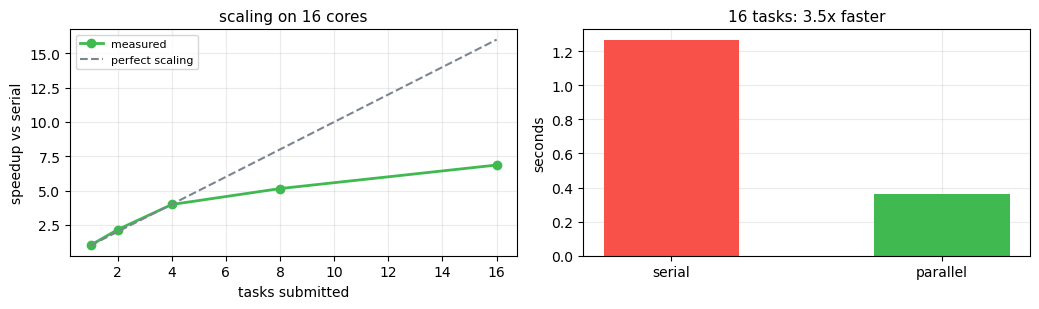

In [7]:
%matplotlib inline
import matplotlib.pyplot as plt
ns = [m[0] for m in measured]; sp = [m[2] for m in measured]
fig, ax = plt.subplots(1, 2, figsize=(10.5, 3.2))
ax[0].plot(ns, sp, "o-", color="#3fb950", lw=2, label="measured")
ax[0].plot(ns, ns, "--", color="#7d8590", label="perfect scaling")
ax[0].set_xlabel("tasks submitted"); ax[0].set_ylabel("speedup vs serial")
ax[0].set_title(f"scaling on {CPUS} cores", fontsize=11); ax[0].legend(fontsize=8)
ax[1].bar(["serial", "parallel"], [t_serial, t_parallel], color=["#f85149", "#3fb950"], width=.5)
ax[1].set_ylabel("seconds"); ax[1].set_title(f"{N} tasks: {t_serial/t_parallel:.1f}x faster", fontsize=11)
for a in ax: a.grid(alpha=.25); a.set_axisbelow(True)
fig.tight_layout(); plt.show()

---
# Part 2 — The object store   ·   deck slides 9

Ray keeps task arguments and results in a **shared-memory object store** on each node. This is
not a detail: it decides whether your parallel code is fast or slower than serial.

If you pass a large object into ten tasks, it is serialised ten times. `ray.put` puts it in the
store **once** and hands the tasks a reference.

<!-- ar -->
<div dir="rtl" lang="ar">

**الجزء الثاني: مخزن الكائنات**

يحفظ Ray مدخلات المهام ونتائجها في **مخزن كائنات بذاكرة مشتركة** على كل عقدة. هذه ليست تفصيلة: هي ما يحدد هل كودك المتوازي سريع أم أبطأ من التشغيل العادي.

إذا مررت كائناً كبيراً إلى عشر مهام، يُحوَّل ويُنقل عشر مرات. أما `ray.put` فيضعه في المخزن **مرة واحدة** ويعطي المهام مرجعاً إليه.

</div>

In [8]:
big = np.random.rand(4_000_000)          # ~32 MB
print(f"array: {big.nbytes/1e6:.0f} MB")

@ray.remote
def mean_of(a):
    return float(a.mean())

# 1. pass the array itself, ten times
t0 = time.perf_counter()
by_value = ray.get([mean_of.remote(big) for _ in range(10)])
t_value = time.perf_counter() - t0

# 2. put it in the store once, pass the reference
handle = ray.put(big)
t0 = time.perf_counter()
by_ref = ray.get([mean_of.remote(handle) for _ in range(10)])
t_ref = time.perf_counter() - t0

assert abs(by_value[0] - by_ref[0]) < 1e-12
print(f"passing the array each time : {t_value:6.3f}s")
print(f"ray.put once, pass the ref  : {t_ref:6.3f}s")
print(f"                              {t_value/max(t_ref,1e-9):5.2f}x")

array: 32 MB
passing the array each time :  0.049s
ray.put once, pass the ref  :  0.015s
                               3.33x


> **The rule:** anything large that several tasks need should be `ray.put` first. Model weights,
> a lookup table, a dataframe. Ray warns you about this in real workloads — a task whose
> arguments are large is the most common cause of "Ray made it slower".
>
> Objects in the store are **immutable**. That is what makes zero-copy sharing safe.

<!-- ar -->
<div dir="rtl" lang="ar">

> **القاعدة:** أي شيء كبير تحتاجه عدة مهام ضعه أولاً بـ `ray.put`: أوزان نموذج، أو جدول بحث، أو جدول بيانات. Ray يحذّرك من هذا في الأعمال الحقيقية، فالمهمة ذات المدخلات الكبيرة هي أشهر سبب لـ «Ray جعله أبطأ».
>
> الكائنات في المخزن **غير قابلة للتعديل**، وهذا ما يجعل مشاركتها دون نسخ آمنة.

</div>

---
# Part 3 — Actors   ·   deck slides 18

A task is stateless. An **actor** is a class whose instance lives in its own process and keeps
state between calls — a loaded model, a connection pool, a running counter.

<!-- ar -->
<div dir="rtl" lang="ar">

**الجزء الثالث: الكائنات الفاعلة**

المهمة بلا حالة. أما **الكائن الفاعل** فهو صنف يعيش في برنامجه الخاص ويحفظ حالته بين الاستدعاءات: نموذج محمّل، أو مجموعة اتصالات، أو عدّاد.

</div>

In [9]:
@ray.remote
class Scorer:
    """A model that is loaded once, then answers many calls."""
    def __init__(self, weights):
        self.w = weights          # imagine 500 MB of model here
        self.n = 0

    def score(self, x):
        self.n += 1
        return float(np.dot(self.w, x))

    def calls(self):
        return self.n


w = np.random.rand(64)
scorer = Scorer.remote(w)                      # one process, holds the weights

vals = ray.get([scorer.score.remote(np.random.rand(64)) for _ in range(50)])
print(f"50 scores, first three: {[round(v,3) for v in vals[:3]]}")
print(f"the actor counted: {ray.get(scorer.calls.remote())} calls -- state survived between them")
assert ray.get(scorer.calls.remote()) == 50

50 scores, first three: [15.692, 15.973, 17.535]
the actor counted: 50 calls -- state survived between them


An **actor** is a worker that keeps state between calls — load the model once, then answer many
requests. A pool of them is the standard serving shape.

<!-- ar -->
<div dir="rtl" lang="ar">

**الكائن الفاعل** عامل يحفظ حالته بين الاستدعاءات: حمّل النموذج مرة، ثم أجب عن طلبات كثيرة. ومجموعة منها هي الشكل المعتاد لتشغيل النماذج.

</div>

In [10]:
# a pool of actors: the standard pattern for "load the model once per worker"
POOL = min(4, CPUS)
pool = [Scorer.remote(w) for _ in range(POOL)]

work = [np.random.rand(64) for _ in range(200)]
t0 = time.perf_counter()
refs = [pool[i % POOL].score.remote(x) for i, x in enumerate(work)]   # round-robin
out = ray.get(refs)
print(f"{len(out)} scores across {POOL} actors in {(time.perf_counter()-t0)*1000:.0f} ms")
print("calls per actor:", ray.get([a.calls.remote() for a in pool]))

200 scores across 4 actors in 386 ms
calls per actor: [50, 50, 50, 50]


| Use a task | Use an actor |
|---|---|
| stateless work | something expensive to set up |
| each call independent | a model, a connection, a cache |
| easy to retry | you need it to stay warm |

**Actors do not scale by themselves.** One actor is one process handling one call at a time; you
create a pool. Ray Serve (session 11) is a managed pool of actors with autoscaling.

<!-- ar -->
<div dir="rtl" lang="ar">

| استخدم مهمة | استخدم كائناً فاعلاً |
|---|---|
| عمل بلا حالة | شيء مكلف في تجهيزه |
| كل استدعاء مستقل | نموذج، أو اتصال، أو ذاكرة مؤقتة |
| سهل الإعادة | تحتاجه أن يبقى جاهزاً |

**الكائنات الفاعلة لا تتوسّع وحدها.** الكائن الواحد برنامج واحد يعالج استدعاءً واحداً في كل مرة، لذلك تصنع مجموعة منها. و Ray Serve (الجلسة ١١) مجموعة كائنات فاعلة مُدارة مع توسّع تلقائي.

</div>

---
# Part 4 — Ray Train   ·   deck slides 20–23

The same PyTorch loop from session 2, distributed. You write a `train_func` that runs on **each**
worker; Ray Train handles process groups, sharding and reporting.

<!-- ar -->
<div dir="rtl" lang="ar">

**الجزء الرابع: Ray Train**

نفس حلقة PyTorch من الجلسة الثانية، لكن موزّعة. تكتب دالة `train_func` تعمل على **كل** عامل، و Ray Train يتولى مجموعات البرامج وتقسيم البيانات وإرسال النتائج.

</div>

In [11]:
import torch
from torch import nn
import ray.train
from ray.train import ScalingConfig, RunConfig
from ray.train.torch import TorchTrainer

# data lives in the object store, so every worker reads one copy
rng = np.random.default_rng(0)
X = rng.normal(size=(8000, 10)).astype("float32")
w_true = rng.normal(size=10)
y = ((X @ w_true + rng.normal(0, .5, 8000)) > 0).astype("float32")
DATA = ray.put((X, y))


@ray.remote
class MetricsLog:
    """A collector actor. ray.train.report is the idiomatic call, but what
    Result.metrics contains has moved between Ray versions -- an actor we own is
    version-proof, and it is a genuinely useful pattern in its own right."""
    def __init__(self):
        self.rows = []

    def add(self, row):
        self.rows.append(row)

    def all(self):
        return self.rows


def train_func(config):
    """Runs on EVERY worker. ray.train.torch prepares the model and the loader."""
    import numpy as np, torch, ray, ray.train
    from torch import nn
    from torch.utils.data import DataLoader, TensorDataset

    X, y = ray.get(config["data"])
    ds = TensorDataset(torch.from_numpy(X), torch.from_numpy(y).unsqueeze(1))
    dl = DataLoader(ds, batch_size=64, shuffle=True)
    dl = ray.train.torch.prepare_data_loader(dl)        # shards across workers

    model = ray.train.torch.prepare_model(
        nn.Sequential(nn.Linear(10, 32), nn.ReLU(), nn.Linear(32, 1)))   # wraps in DDP
    opt = torch.optim.AdamW(model.parameters(), lr=3e-3)
    loss_fn = nn.BCEWithLogitsLoss()
    rank = ray.train.get_context().get_world_rank()

    for epoch in range(config["epochs"]):
        model.train(); total = 0.0; n = 0
        for xb, yb in dl:
            opt.zero_grad(set_to_none=True)
            loss = loss_fn(model(xb), yb)
            loss.backward(); opt.step()
            total += loss.item() * len(xb); n += len(xb)
        row = {"rank": rank, "epoch": epoch, "loss": total / max(n, 1), "rows_seen": n}
        ray.train.report(row)                     # idiomatic: Tune and checkpointing use it
        ray.get(config["log"].add.remote(row))    # and ours, which we can read back


log = MetricsLog.remote()
WORKERS = 2
trainer = TorchTrainer(
    train_loop_per_worker=train_func,
    train_loop_config={"epochs": 5, "data": DATA, "log": log},
    scaling_config=ScalingConfig(num_workers=WORKERS, use_gpu=False),
    run_config=RunConfig(storage_path=os.path.abspath("ray_results"), name="demo"),
)
result = trainer.fit()
ok = result.error is None
print(f"finished on {WORKERS} workers; trainer reported failure: {not ok}")
assert ok, result.error


finished on 2 workers; trainer reported failure: False


Each worker logged its own losses to an actor. Reading them back proves the data really was
**sharded**: each worker saw half the rows, not all of them twice.

<!-- ar -->
<div dir="rtl" lang="ar">

كل عامل سجّل خسائره في كائن فاعل. قراءتها تثبت أن البيانات **قُسّمت** فعلاً: كل عامل رأى نصف الصفوف، لا كلها مرتين.

</div>

In [12]:

hist = pd.DataFrame(ray.get(log.all.remote())).sort_values(["epoch", "rank"])
print(hist.to_string(index=False))

per_epoch = hist.groupby("epoch").loss.mean()
print(f"\nmean loss: epoch 0 {per_epoch.iloc[0]:.4f}  ->  epoch {per_epoch.index[-1]} "
      f"{per_epoch.iloc[-1]:.4f}")
print(f"each worker saw {int(hist.rows_seen.iloc[0])} of {len(X)} rows -- the loader sharded the data")

assert len(hist) == WORKERS * 5, "every worker should report every epoch"
assert per_epoch.iloc[-1] < per_epoch.iloc[0], "the loss must come down"
assert hist.rows_seen.iloc[0] < len(X), "prepare_data_loader must shard, not duplicate"


 rank  epoch     loss  rows_seen
    0      0 0.474545       4000
    1      0 0.481300       4000
    0      1 0.212683       4000
    1      1 0.218455       4000
    0      2 0.152412       4000
    1      2 0.157448       4000
    0      3 0.140032       4000
    1      3 0.144730       4000
    0      4 0.136301       4000
    1      4 0.140867       4000

mean loss: epoch 0 0.4779  ->  epoch 4 0.1386
each worker saw 4000 of 8000 rows -- the loader sharded the data


### What changed versus session 2

| Session 2 | Ray Train |
|---|---|
| your loop, one process | the same loop, on N workers |
| `DataLoader(ds)` | `prepare_data_loader(dl)` — shards the data |
| `model` | `prepare_model(model)` — wraps in DDP |
| `print(loss)` | `ray.train.report({...})` |
| `num_workers=2` | `ScalingConfig(num_workers=100, use_gpu=True)` |

**Only the last row changes when you get a cluster.** That is the argument for Ray Train over
writing `torchrun` plumbing yourself.

<!-- ar -->
<div dir="rtl" lang="ar">

**ما الذي تغيّر مقارنة بالجلسة الثانية**

| الجلسة الثانية | Ray Train |
|---|---|
| حلقتك في برنامج واحد | نفس الحلقة على N عامل |
| `DataLoader(ds)` | `prepare_data_loader(dl)`: يقسّم البيانات |
| `model` | `prepare_model(model)`: يغلّفه للتدريب الموزّع |
| `print(loss)` | `ray.train.report({...})` |
| `num_workers=2` | `ScalingConfig(num_workers=100, use_gpu=True)` |

**السطر الأخير وحده يتغيّر عندما يصبح عندك عنقود.** وهذا سبب تفضيل Ray Train على كتابة تفاصيل `torchrun` بنفسك.

</div>

---
# Part 5 — Advanced   ·   deck slides 24–27

## Step 5.1 · `ray.wait` — take results as they finish

`ray.get(refs)` waits for **all** of them. If tasks vary in length, you sit idle. `ray.wait`
hands you whichever finished first.

<!-- ar -->
<div dir="rtl" lang="ar">

**الجزء الخامس: متقدم**

**الخطوة ٥٫١ · `ray.wait`: خذ النتائج فور انتهائها**

`ray.get(refs)` ينتظر **كل** المهام. إذا اختلفت أطوالها فستبقى تنتظر بلا عمل. أما `ray.wait` فيعطيك أول ما ينتهي منها.

</div>

In [13]:
@ray.remote
def variable(i):
    time.sleep(0.1 + (i % 4) * 0.25)
    return i

refs = [variable.remote(i) for i in range(8)]
done_order, pending = [], refs
t0 = time.perf_counter()
while pending:
    ready, pending = ray.wait(pending, num_returns=1)
    got = ray.get(ready[0])
    done_order.append(got)
    print(f"  {time.perf_counter()-t0:5.2f}s  finished task {got}  ({len(pending)} left)")
print("\ncompletion order:", done_order)
print("With ray.get you would have waited for the slowest before touching any result.")

   0.10s  finished task 0  (7 left)
   0.10s  finished task 4  (6 left)
   0.35s  finished task 1  (5 left)
   0.36s  finished task 5  (4 left)
   0.60s  finished task 2  (3 left)
   0.61s  finished task 6  (2 left)
   0.85s  finished task 3  (1 left)
   0.86s  finished task 7  (0 left)

completion order: [0, 4, 1, 5, 2, 6, 3, 7]
With ray.get you would have waited for the slowest before touching any result.


## Step 5.2 · Resources, and the rest of the toolkit

```python
# ask for what a task actually needs; Ray schedules accordingly
@ray.remote(num_cpus=2, num_gpus=0.5, memory=2 * 1024**3)
def heavy(x): ...

# retries are one argument
@ray.remote(max_retries=3, retry_exceptions=True)
def flaky(x): ...

# limit concurrency so you do not flood a database
from ray.util.actor_pool import ActorPool
pool = ActorPool([Worker.remote() for _ in range(4)])

# hyperparameter search, same idea as tasks
from ray import tune
tune.Tuner(trainable, param_space={"lr": tune.loguniform(1e-4, 1e-1)}).fit()

# a real cluster -- the only line that changes
ray.init(address="ray://head-node:10001")
```

| Symptom | Cause |
|---|---|
| "Ray made it slower" | tasks too small — batch them; each has ~1 ms overhead |
| memory spikes on the driver | you called `ray.get` on everything at once |
| the same big object serialised repeatedly | you forgot `ray.put` |
| workers idle | too few tasks, or one huge task blocking |
| out of object-store memory | results too large; write to disk and pass paths |

<!-- ar -->
<div dir="rtl" lang="ar">

**الخطوة ٥٫٢ · الموارد، وبقية الأدوات**

الكود أعلاه يعرض بإيجاز: كيف تطلب ما تحتاجه المهمة من معالجات وكرت شاشة وذاكرة، وكيف تصبح إعادة المحاولة معاملاً واحداً، وكيف تحدّ عدد العمليات المتزامنة بمجموعة كائنات فاعلة، وكيف تبحث عن أفضل الإعدادات بـ Ray Tune، وأن السطر الوحيد الذي يتغيّر لعنقود حقيقي هو عنوان `ray.init`.

| العَرَض | السبب |
|---|---|
| «Ray جعله أبطأ» | المهام صغيرة جداً؛ اجمعها، فلكل مهمة تكلفة ~١ ملّي ثانية |
| ارتفاع الذاكرة في البرنامج الرئيسي | استدعيت `ray.get` على كل شيء مرة واحدة |
| نفس الكائن الكبير يُنقل مرات كثيرة | نسيت `ray.put` |
| العمّال بلا عمل | مهام قليلة جداً، أو مهمة ضخمة واحدة تعطّل الباقي |
| امتلأت ذاكرة مخزن الكائنات | النتائج كبيرة جداً؛ اكتبها على القرص وأرسل المسارات |

</div>

## Step 5.3 · When *not* to use Ray

| Situation | Better |
|---|---|
| A tight numpy loop | vectorise it. numpy already uses your cores |
| Thousands of tiny tasks | batch them — do 1,000 items per task, not one |
| A single-machine dataframe job | pandas, polars, or duckdb |
| Pure I/O waiting | `asyncio` or threads; you are not CPU-bound |
| Training that fits on one GPU | plain PyTorch. DDP has real overhead |

Ray earns its place when the work is **CPU-bound, chunky, and does not fit in one process** —
or when you genuinely have more than one machine.

<!-- ar -->
<div dir="rtl" lang="ar">

**الخطوة ٥٫٣ · متى *لا* تستخدم Ray**

| الحالة | الأفضل |
|---|---|
| حلقة numpy قصيرة ومكثفة | حوّلها لعمليات على المصفوفة كاملة؛ numpy يستخدم أنويتك أصلاً |
| آلاف المهام الصغيرة جداً | اجمعها: ١٠٠٠ عنصر في كل مهمة، لا عنصراً واحداً |
| عمل على جدول بيانات في جهاز واحد | pandas أو polars أو duckdb |
| انتظار قراءة وكتابة فقط | `asyncio` أو الخيوط؛ المعالج ليس المشكلة |
| تدريب يكفيه كرت شاشة واحد | PyTorch العادي؛ التوزيع له تكلفة حقيقية |

Ray يستحق مكانه عندما يكون العمل **حساباً ثقيلاً، ومقسّماً، ولا يتسع في برنامج واحد**، أو عندما يكون عندك فعلاً أكثر من جهاز.

</div>

---
# Reference — worth knowing, not demonstrated here

| Topic | One-line version |
|---|---|
| Ray Data | streaming datasets that do not fit in memory, with `map_batches` |
| Ray Tune | search spaces, schedulers, early stopping of bad trials |
| Ray Serve | managed actor pools for serving — session 11 |
| Real clusters | `ray up cluster.yaml`, autoscaling, head vs worker nodes |
| Fault tolerance | task retries, actor restarts, and what is *not* recovered |
| The dashboard | `ray.init(include_dashboard=True)` then localhost:8265 |

## Recap

| You wanted to… | Do this |
|---|---|
| run a function elsewhere | `@ray.remote` + `f.remote(x)` |
| get the answer | `ray.get(ref)` |
| share a large object | `ray.put(obj)` once, pass the handle |
| keep state warm | an actor, and a pool of them |
| take results as they land | `ray.wait(refs, num_returns=1)` |
| distribute a PyTorch loop | `TorchTrainer` + `prepare_model` + `prepare_data_loader` |
| use a cluster | `ray.init(address=...)` — and nothing else changes |
| ask for a GPU | `@ray.remote(num_gpus=1)` |

## What to do at work tomorrow

1. Find the slowest loop you have that is CPU-bound and independent per item.
2. Time it serially and **write the number down**.
3. Add `@ray.remote`, submit, `ray.get`. Compare. If it is not faster, your tasks are too small —
   batch them.
4. `ray.put` anything large that every task needs.
5. Only reach for a cluster once one machine is genuinely full.

<!-- ar -->
<div dir="rtl" lang="ar">

**مرجع: يستحق المعرفة، ولم نجرّبه هنا**

| الموضوع | بسطر واحد |
|---|---|
| Ray Data | بيانات متدفقة لا تتسع في الذاكرة، مع `map_batches` |
| Ray Tune | مجالات بحث، وجدولة، وإيقاف مبكر للتجارب السيئة |
| Ray Serve | مجموعات كائنات فاعلة مُدارة لتشغيل النماذج؛ الجلسة ١١ |
| عناقيد حقيقية | `ray up cluster.yaml`، والتوسّع التلقائي، والعقدة الرئيسية مقابل العاملة |
| تحمّل الأعطال | إعادة المهام، وإعادة تشغيل الكائنات الفاعلة، وما *لا* يُستعاد |
| لوحة المعلومات | `ray.init(include_dashboard=True)` ثم localhost:8265 |

**الخلاصة**

| تريد أن… | افعل هذا |
|---|---|
| تشغّل دالة في مكان آخر | `@ray.remote` ثم `f.remote(x)` |
| تحصل على الجواب | `ray.get(ref)` |
| تشارك كائناً كبيراً | `ray.put(obj)` مرة، ومرّر المرجع |
| تُبقي الحالة جاهزة | كائن فاعل، ومجموعة منها |
| تأخذ النتائج فور وصولها | `ray.wait(refs, num_returns=1)` |
| توزّع حلقة PyTorch | `TorchTrainer` مع `prepare_model` و `prepare_data_loader` |
| تستخدم عنقوداً | `ray.init(address=...)`، ولا شيء آخر يتغيّر |
| تطلب كرت شاشة | `@ray.remote(num_gpus=1)` |

**ماذا تفعل في العمل غداً**

1. ابحث عن أبطأ حلقة عندك تعتمد على المعالج، وكل عنصر فيها مستقل.
2. قِس وقتها بالتشغيل العادي، و**اكتب الرقم**.
3. أضف `@ray.remote`، وأرسل، ثم `ray.get`، وقارن. إذا لم يصبح أسرع فالمهام صغيرة جداً، فاجمعها.
4. ضع بـ `ray.put` أي شيء كبير تحتاجه كل المهام.
5. لا تنتقل إلى عنقود إلا عندما يمتلئ جهاز واحد فعلاً.

</div>

## Cleanup

<!-- ar -->
<div dir="rtl" lang="ar">

**التنظيف**

</div>

In [14]:
import shutil, os
ray.shutdown()
print("ray shut down")
os.chdir(BASE)
shutil.rmtree(PROJ, ignore_errors=True)
print("sandbox removed")

ray shut down
sandbox removed
